# CP1: Обработка и подготовка данных

## Источник данных
- **Название**: Medical Insurance Cost Prediction
- **Ссылка**: https://www.kaggle.com/datasets/mohankrishnathalla/medical-insurance-cost-prediction
- **Тип на Kaggle**: Monetary (annual_medical_cost)
- **Почему выбран**: 
  - Содержит денежную целевую переменную (annual_medical_cost)
  - 100,000 строк и 54 колонки - подходит по критерям для проекта
  - Подходит для задачи регрессии
  - Не является Getting Started

## Medical Insurance Cost Prediction

### Источник данных
- **Kaggle**: Medical Insurance Cost Prediction
- **Автор**: Mohan Krishna Thalla
- **Ссылка**: https://www.kaggle.com/datasets/mohankrishnathalla/medical-insurance-cost-prediction
- **Тип**: Monetary (annual_medical_cost)
- **Строк**: 100,000
- **Колонок**: 54

### Почему выбран этот датасет?
1.  Monetary датасет (целевая переменная - медицинские расходы)
2.  100,000 строк - достаточно для обучения
3.  54 признака - большой выбор для фич
4.  Не Getting Started (реальные данные с пропусками)
5.  Подходит для задачи регрессии

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Фикс seed для воспроизводимости
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Библиотеки загружены")
print(f"Pandas version: {pd.__version__}")

Библиотеки загружены
Pandas version: 2.2.2


In [77]:
df = pd.read_csv('medical_insurance.csv')

print("ДАТАСЕТ ЗАГРУЖЕН")
print(f"Строк: {df.shape[0]:,}")
print(f"Столбцов: {df.shape[1]}")
print(f"\nНазвания колонок:")
print(df.columns.tolist())

ДАТАСЕТ ЗАГРУЖЕН
Строк: 100,000
Столбцов: 54

Названия колонок:
['person_id', 'age', 'sex', 'region', 'urban_rural', 'income', 'education', 'marital_status', 'employment_status', 'household_size', 'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'risk_score', 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']


In [78]:
print("ПЕРВЫЕ 5 СТРОК")
display(df.head())

print("\n ПОСЛЕДНИЕ 5 СТРОК")
display(df.tail())

print("\n ТИПЫ ДАННЫХ ")
print(df.dtypes)

ПЕРВЫЕ 5 СТРОК


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0



 ПОСЛЕДНИЕ 5 СТРОК


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
99995,6266,50,Male,West,Urban,127200.0,No HS,Married,Employed,2,...,0,0,0,0,0,1,0,0,0,0
99996,54887,42,Male,East,Suburban,21600.0,HS,Married,Employed,2,...,0,0,0,0,0,0,0,0,0,0
99997,76821,41,Male,West,Rural,81900.0,HS,Divorced,Unemployed,1,...,0,0,0,1,0,1,0,0,0,0
99998,861,51,Female,South,Urban,43400.0,Doctorate,Single,Unemployed,3,...,0,0,1,0,0,2,2,1,0,0
99999,15796,44,Female,South,Rural,43700.0,Some College,Married,Employed,2,...,0,0,0,0,0,1,1,1,0,0



 ТИПЫ ДАННЫХ 
person_id                        int64
age                              int64
sex                             object
region                          object
urban_rural                     object
income                         float64
education                       object
marital_status                  object
employment_status               object
household_size                   int64
dependents                       int64
bmi                            float64
smoker                          object
alcohol_freq                    object
visits_last_year                 int64
hospitalizations_last_3yrs       int64
days_hospitalized_last_3yrs      int64
medication_count                 int64
systolic_bp                    float64
diastolic_bp                   float64
ldl                            float64
hba1c                          float64
plan_type                       object
network_tier                    object
deductible                       int64
copay     

In [52]:
print(" СТАТИСТИКА ЧИСЛОВЫХ ПРИЗНАКОВ ")
display(df.describe())

print("\n ТИПЫ ДАННЫХ ")
print(df.dtypes)

print("\n ИНФОРМАЦИЯ О ДАТАСЕТЕ ")
df.info()

 СТАТИСТИКА ЧИСЛОВЫХ ПРИЗНАКОВ 


,person_id,age,income,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
mean,50000.500000,47.521500,4.987390e+04,2.430900,0.898380,26.990512,1.92765,0.093640,0.373350,1.236320,...,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,4.680021e+04,1.075126,0.950654,4.994883,1.73773,0.304848,1.373011,1.209358,...,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,1.100000e+03,1.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,2.110000e+04,2.000000,0.000000,23.600000,1.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,3.620000e+04,2.000000,1.000000,27.000000,2.00000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
75%,75000.250000,58.000000,6.220000e+04,3.000000,1.000000,30.400000,3.00000,0.000000,0.000000,2.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000
max,100000.000000,100.000000,1.061800e+06,9.000000,7.000000,50.400000,25.00000,3.000000,21.000000,11.000000,...,1.000000,1.000000,1.000000,7.000000,6.000000,7.000000,7.00000,7.000000,1.000000,1.000000



 ТИПЫ ДАННЫХ 
person_id                        int64
age                              int64
sex                             object
region                          object
urban_rural                     object
income                         float64
education                       object
marital_status                  object
employment_status               object
household_size                   int64
dependents                       int64
bmi                            float64
smoker                          object
alcohol_freq                    object
visits_last_year                 int64
hospitalizations_last_3yrs       int64
days_hospitalized_last_3yrs      int64
medication_count                 int64
systolic_bp                    float64
diastolic_bp                   float64
ldl                            float64
hba1c                          float64
plan_type                       object
network_tier                    object
deductible                       int64
copay     

In [79]:
print("ПРОПУСКИ В ДАННЫХ")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Пропуски': missing, 'Процент': missing_pct})
missing_df = missing_df[missing_df['Пропуски'] > 0].sort_values('Процент', ascending=False)

if len(missing_df) > 0:
    print(f"Найдены пропуски в {len(missing_df)} колонках:")
    display(missing_df)
else:
    print(" Пропусков нет!")

ПРОПУСКИ В ДАННЫХ
Найдены пропуски в 1 колонках:


,Пропуски,Процент
alcohol_freq,30083,30.083


In [80]:
print("ДУБЛИКАТЫ")
duplicates = df.duplicated().sum()
print(f"Полных дубликатов строк: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Дубликаты удалены. Осталось строк: {df.shape[0]:,}")
else:
    print(" Дубликатов нет!")

ДУБЛИКАТЫ
Полных дубликатов строк: 0
 Дубликатов нет!


АНАЛИЗ ТАРГЕТА
Целевая переменная: annual_medical_cost
Min: 55.55
Max: 65,724.90
Mean: 3,009.45
Median: 2,082.57
Стандартное отклонение: 3,127.46


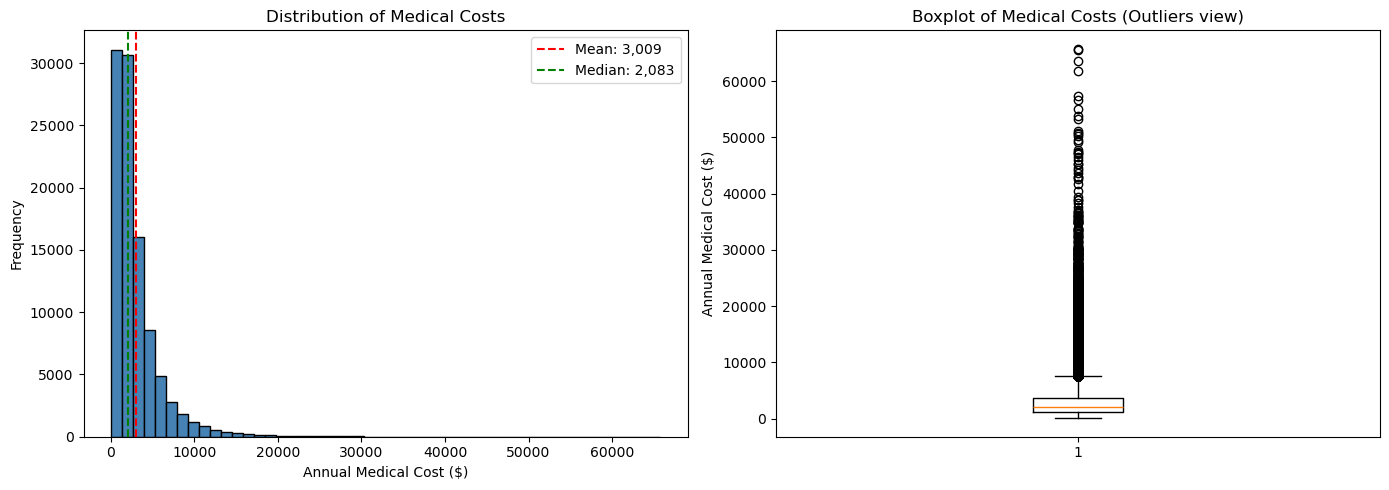


Асимметрия (skewness): 4.03
Сильная положительная асимметрия → возможно понадобится логарифмирование


In [81]:
# Определяем целевую переменную
target = 'annual_medical_cost'

print("АНАЛИЗ ТАРГЕТА")
print(f"Целевая переменная: {target}")
print(f"Min: {df[target].min():,.2f}")
print(f"Max: {df[target].max():,.2f}")
print(f"Mean: {df[target].mean():,.2f}")
print(f"Median: {df[target].median():,.2f}")
print(f"Стандартное отклонение: {df[target].std():,.2f}")

# Графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(df[target], bins=50, edgecolor='black', color='steelblue')
axes[0].set_xlabel('Annual Medical Cost ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Medical Costs')
axes[0].axvline(df[target].mean(), color='red', linestyle='--', label=f'Mean: {df[target].mean():,.0f}')
axes[0].axvline(df[target].median(), color='green', linestyle='--', label=f'Median: {df[target].median():,.0f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(df[target])
axes[1].set_ylabel('Annual Medical Cost ($)')
axes[1].set_title('Boxplot of Medical Costs (Outliers view)')

plt.tight_layout()
plt.show()

# Асимметрия
skewness = df[target].skew()
print(f"\nАсимметрия (skewness): {skewness:.2f}")
if skewness > 1:
    print("Сильная положительная асимметрия → возможно понадобится логарифмирование")

In [82]:
print("ПРЕДВАРИТЕЛЬНЫЙ ИТОГ")
print(f" Датасет загружен: {df.shape[0]:,} строк, {df.shape[1]} колонок")
print(f" Monetary датасет (целевая переменная - annual_medical_cost)")
print(f" Пропуски: {'есть' if len(missing_df) > 0 else 'нет'}")
print(f" Дубликаты: {duplicates}")
print(f"\n Тип задачи: РЕГРЕССИЯ (предсказание medical costs)")

ПРЕДВАРИТЕЛЬНЫЙ ИТОГ
 Датасет загружен: 100,000 строк, 54 колонок
 Monetary датасет (целевая переменная - annual_medical_cost)
 Пропуски: есть
 Дубликаты: 0

 Тип задачи: РЕГРЕССИЯ (предсказание medical costs)


АНАЛИЗ ПРОПУСКОВ
Найдено 1 колонок с пропусками:



,Количество пропусков,Процент
alcohol_freq,30083,30.083


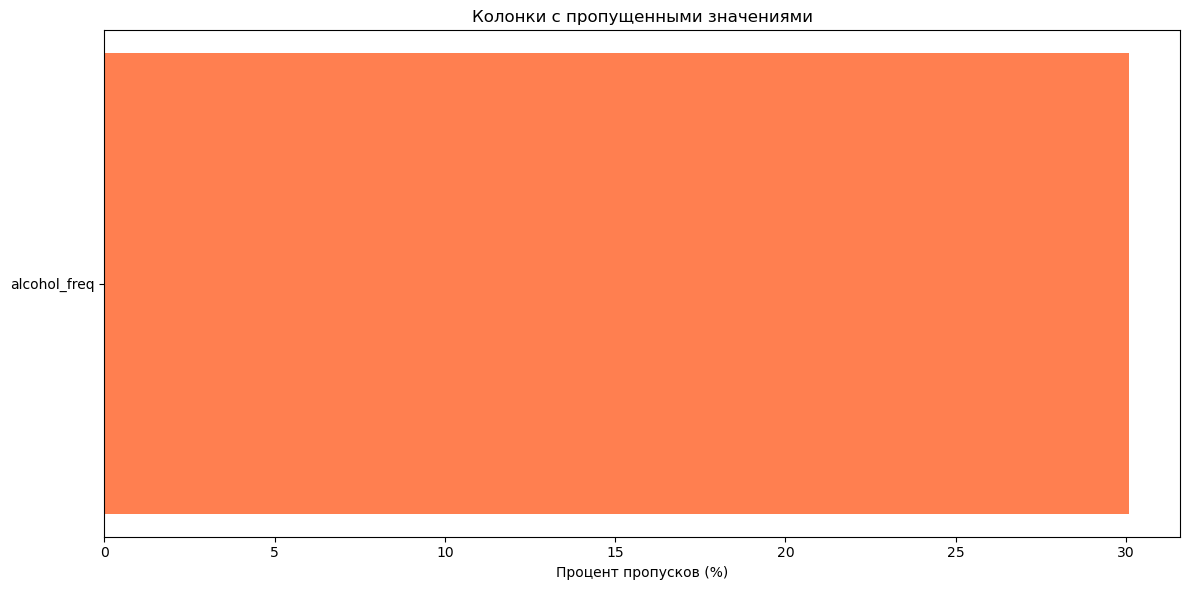

In [83]:
print("АНАЛИЗ ПРОПУСКОВ")

# Все колонки с пропусками
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Количество пропусков': missing, 'Процент': missing_pct})
missing_df = missing_df[missing_df['Количество пропусков'] > 0].sort_values('Процент', ascending=False)

print(f"Найдено {len(missing_df)} колонок с пропусками:\n")
display(missing_df)

# Визуализация пропусков
plt.figure(figsize=(12, 6))
plt.barh(missing_df.index, missing_df['Процент'], color='coral')
plt.xlabel('Процент пропусков (%)')
plt.title('Колонки с пропущенными значениями')
plt.tight_layout()
plt.show()

АНАЛИЗ КОЛОНКИ С ПРОПУСКАМИ: alcohol_freq 
Уникальные значения в alcohol_freq:
alcohol_freq
Occasional    45078
NaN           30083
Weekly        19833
Daily          5006
Name: count, dtype: int64

Тип данных: object


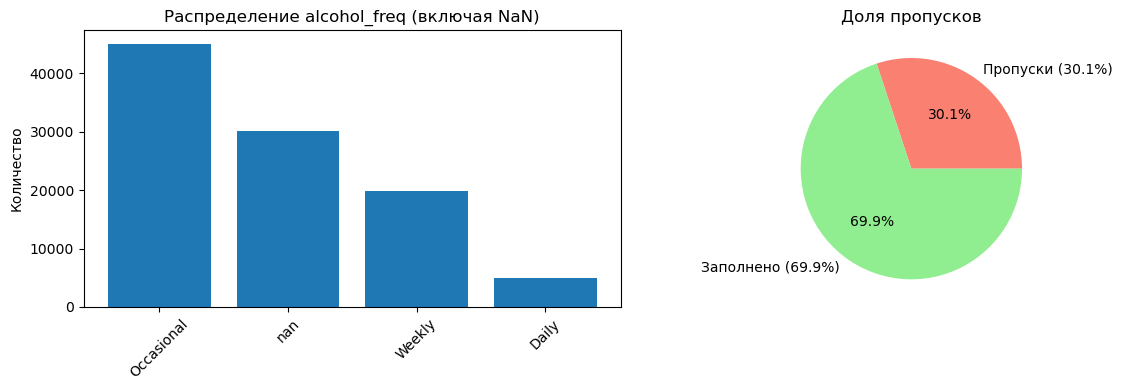

In [84]:
print("АНАЛИЗ КОЛОНКИ С ПРОПУСКАМИ: alcohol_freq ")

# Смотрим уникальные значения
print(f"Уникальные значения в alcohol_freq:")
print(df['alcohol_freq'].value_counts(dropna=False))

# Что за значения?
print(f"\nТип данных: {df['alcohol_freq'].dtype}")

# Визуализация ДО обработки
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Распределение
values = df['alcohol_freq'].value_counts(dropna=False)
axes[0].bar(range(len(values)), values.values, tick_label=[str(x) for x in values.index])
axes[0].set_xticklabels([str(x) for x in values.index], rotation=45)
axes[0].set_title('Распределение alcohol_freq (включая NaN)')
axes[0].set_ylabel('Количество')

# Процент пропусков
missing_pct = (df['alcohol_freq'].isnull().sum() / len(df)) * 100
axes[1].pie([missing_pct, 100-missing_pct], 
            labels=[f'Пропуски ({missing_pct:.1f}%)', f'Заполнено ({100-missing_pct:.1f}%)'],
            colors=['salmon', 'lightgreen'], autopct='%1.1f%%')
axes[1].set_title('Доля пропусков')

plt.tight_layout()
plt.show()

In [85]:
print("ВЫБОР СТРАТЕГИИ ДЛЯ ЗАПОЛНЕНИЯ ПРОПУСКОВ")

# Посмотрим на распределение существующих значений
print("Распределение среди непропущенных значений:")
print(df['alcohol_freq'].value_counts(normalize=True))

mode_value = df['alcohol_freq'].mode()[0]
print(f"\nСамое частое значение (мода): '{mode_value}'")

# Стратегия: создаем отдельную категорию для пропусков
df['alcohol_freq_known'] = df['alcohol_freq'].fillna('Unknown')
print("\n Стратегия 1: Создана новая колонка 'alcohol_freq_known' с категорией 'Unknown'")

# Проверка
print(f"\nНовые значения в alcohol_freq_known:")
print(df['alcohol_freq_known'].value_counts())

# Удаляем исходную колонку (чтобы не было дублирования)
df = df.drop(columns=['alcohol_freq'])
print("\n Исходная колонка 'alcohol_freq' удалена (заменена на 'alcohol_freq_known')")

# Проверяем, что пропусков больше нет
print(f"\nПроверка: осталось пропусков в датасете? {df.isnull().sum().sum()}")

ВЫБОР СТРАТЕГИИ ДЛЯ ЗАПОЛНЕНИЯ ПРОПУСКОВ
Распределение среди непропущенных значений:
alcohol_freq
Occasional    0.644736
Weekly        0.283665
Daily         0.071599
Name: proportion, dtype: float64

Самое частое значение (мода): 'Occasional'

 Стратегия 1: Создана новая колонка 'alcohol_freq_known' с категорией 'Unknown'

Новые значения в alcohol_freq_known:
alcohol_freq_known
Occasional    45078
Unknown       30083
Weekly        19833
Daily          5006
Name: count, dtype: int64

 Исходная колонка 'alcohol_freq' удалена (заменена на 'alcohol_freq_known')

Проверка: осталось пропусков в датасете? 0


АНАЛИЗ ВЫБРОСОВ
Числовых признаков: 44

=== ТАРГЕТ: annual_medical_cost ===
Кол-во выбросов: 6,772
Процент выбросов: 6.77%
Нижняя граница: $-2,624.14
Верхняя граница: $7,507.22


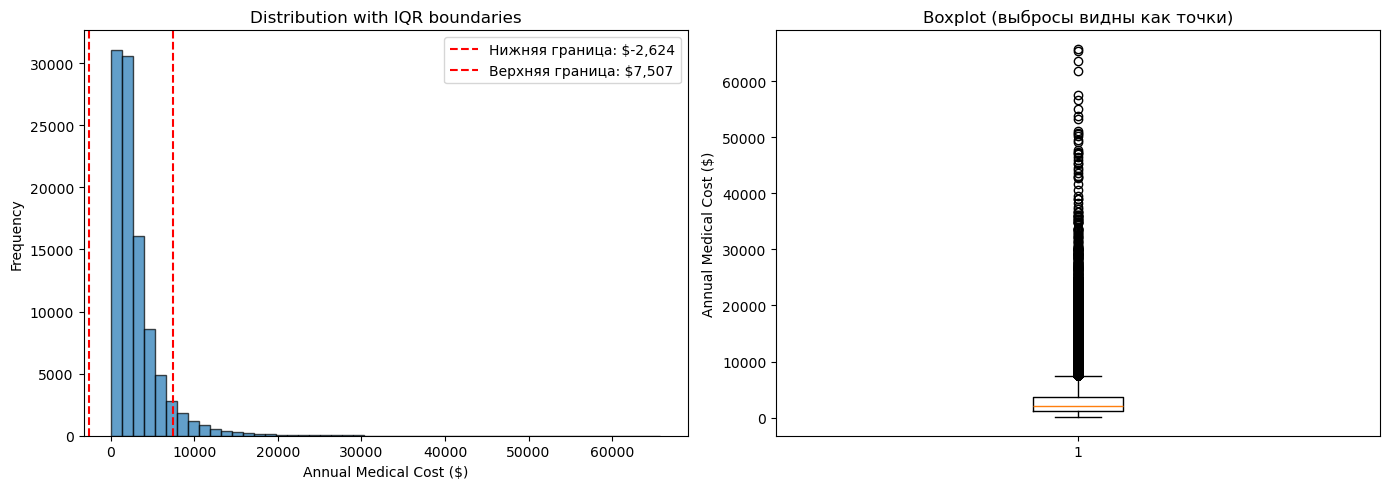

In [86]:
print("АНАЛИЗ ВЫБРОСОВ")

# Выбираем только числовые колонки
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Числовых признаков: {len(numeric_cols)}")

# Функция для поиска выбросов через IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Анализируем выбросы для ТАРГЕТА
target = 'annual_medical_cost'
n_outliers, lb, ub = detect_outliers_iqr(df, target)

print(f"\n=== ТАРГЕТ: {target} ===")
print(f"Кол-во выбросов: {n_outliers:,}")
print(f"Процент выбросов: {(n_outliers/len(df))*100:.2f}%")
print(f"Нижняя граница: ${lb:,.2f}")
print(f"Верхняя граница: ${ub:,.2f}")

# Визуализация выбросов в таргете
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(df[target], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(lb, color='red', linestyle='--', label=f'Нижняя граница: ${lb:,.0f}')
axes[0].axvline(ub, color='red', linestyle='--', label=f'Верхняя граница: ${ub:,.0f}')
axes[0].set_xlabel('Annual Medical Cost ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution with IQR boundaries')
axes[0].legend()

# Boxplot
axes[1].boxplot(df[target])
axes[1].set_ylabel('Annual Medical Cost ($)')
axes[1].set_title('Boxplot (выбросы видны как точки)')

plt.tight_layout()
plt.show()

In [87]:
print("ОБРАБОТКА ВЫБРОСОВ")

# Ограничиваем выбросы в таргете
before_count = len(df[df[target] > ub])
df[target] = df[target].clip(upper=ub)

print(f" {target}: {before_count} выбросов ограничено до ${ub:,.2f}")

# Проверка после обработки
n_outliers_after, _, _ = detect_outliers_iqr(df, target)
print(f"Выбросов после обработки: {n_outliers_after}")

ОБРАБОТКА ВЫБРОСОВ
 annual_medical_cost: 6772 выбросов ограничено до $7,507.22
Выбросов после обработки: 0


КОРРЕЛЯЦИЯ С ТАРГЕТОМ
ТОП10 признаков, наиболее коррелирующих с medical cost:


annual_medical_cost            1.000000
monthly_premium                0.830736
annual_premium                 0.830736
total_claims_paid              0.616772
avg_claim_amount               0.559331
risk_score                     0.350969
chronic_count                  0.330474
is_high_risk                   0.288636
days_hospitalized_last_3yrs    0.225060
visits_last_year               0.214299
Name: annual_medical_cost, dtype: float64


ТОП10 признаков с отрицательной корреляцией (снижают расходы):


ldl                         0.020722
dependents                  0.003993
household_size              0.003400
policy_term_years           0.002051
policy_changes_last_2yrs    0.000301
copay                      -0.000189
deductible                 -0.001481
person_id                  -0.001713
provider_quality           -0.002901
income                     -0.008298
Name: annual_medical_cost, dtype: float64

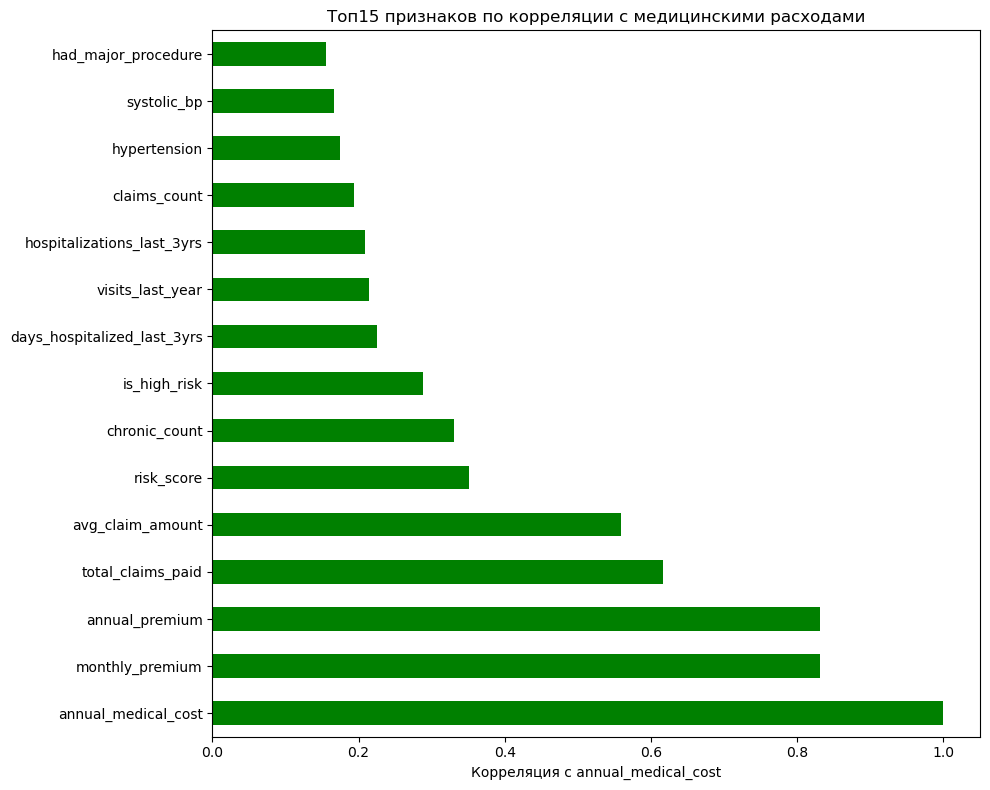

In [88]:
print("КОРРЕЛЯЦИЯ С ТАРГЕТОМ")

# Все числовые колонки (исключая нечисловые)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
target = 'annual_medical_cost'

# Корреляция всех признаков с целевой переменной
correlations = df[numeric_cols].corr()[target].sort_values(ascending=False)

print("ТОП10 признаков, наиболее коррелирующих с medical cost:")
display(correlations.head(10))

print("\nТОП10 признаков с отрицательной корреляцией (снижают расходы):")
display(correlations.tail(10))

# Визуализация
plt.figure(figsize=(10, 8))
top_features = correlations.head(15)
colors = ['red' if x < 0 else 'green' for x in top_features.values]
top_features.plot(kind='barh', color=colors)
plt.xlabel('Корреляция с annual_medical_cost')
plt.title('Топ15 признаков по корреляции с медицинскими расходами')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

In [90]:
print("ПРОВЕРКА НА DATA LEAK")

# Проверяем связь премии и расходов
potential_leak_features = ['monthly_premium', 'annual_premium', 'total_claims_paid', 'avg_claim_amount']

for feature in potential_leak_features:
    print(f"\n{feature}:")
    print(f"  Корреляция с таргетом: {df[feature].corr(df[target]):.4f}")
    
    # Проверяем, не является ли признак просто умножением/делением таргета
    if feature == 'monthly_premium':
        ratio = (df[target] / df[feature]).mean()
        print(f"  Среднее отношение annual_cost / monthly_premium: {ratio:.2f} (должно быть ~12 если monthly)")

ПРОВЕРКА НА DATA LEAK

monthly_premium:
  Корреляция с таргетом: 0.8307
  Среднее отношение annual_cost / monthly_premium: 51.87 (должно быть ~12 если monthly)

annual_premium:
  Корреляция с таргетом: 0.8307

total_claims_paid:
  Корреляция с таргетом: 0.6168

avg_claim_amount:
  Корреляция с таргетом: 0.5593


In [91]:
print("ВЫБОР МЕТРИК КАЧЕСТВА")
print("""
Тип задачи: РЕГРЕССИЯ

Метрики:
- RMSE (Root Mean Squared Error) - ОСНОВНАЯ
   Штрафует большие ошибки
   В долларах
  
- MAE (Mean Absolute Error) - ВСПОМОГАТЕЛЬНАЯ
   Устойчива к выбросам

- R² (R-squared) - ДОПОЛНИТЕЛЬНАЯ
   Доля объясненной дисперсии

ПРИОРИТЕТ: RMSE
""")

ВЫБОР МЕТРИК КАЧЕСТВА

Тип задачи: РЕГРЕССИЯ

Метрики:
- RMSE (Root Mean Squared Error) - ОСНОВНАЯ
   Штрафует большие ошибки
   В долларах
  
- MAE (Mean Absolute Error) - ВСПОМОГАТЕЛЬНАЯ
   Устойчива к выбросам

- R² (R-squared) - ДОПОЛНИТЕЛЬНАЯ
   Доля объясненной дисперсии

ПРИОРИТЕТ: RMSE



In [92]:
print("FEATURE ENGINEERING")

original_features = df.shape[1]

# 1. Возрастные группы
if 'age' in df.columns:
    df['age_group'] = pd.cut(df['age'], 
                              bins=[0, 30, 40, 50, 60, 70, 100], 
                              labels=['<30', '30-39', '40-49', '50-59', '60-69', '70+'])
    print(" Создан 'age_group' (6 возрастных категорий)")

# 2. BMI категории (ВОЗ стандарт)
if 'bmi' in df.columns:
    df['bmi_category'] = pd.cut(df['bmi'], 
                                 bins=[0, 18.5, 25, 30, 35, 40, 100], 
                                 labels=['Underweight', 'Normal', 'Overweight', 'Obese Class I', 
                                        'Obese Class II', 'Obese Class III'])
    print(" Создан 'bmi_category' (категории ИМТ по ВОЗ)")

# 3. Соотношение расходов к доходу
if 'income' in df.columns and target in df.columns:
    df['cost_to_income_ratio'] = df[target] / (df['income'] + 1)
    print(" Создан 'cost_to_income_ratio' (% от дохода на медицину)")

# 4. Количество хронических заболеваний
chronic_cols = ['hypertension', 'diabetes', 'copd', 'cardiovascular', 'cancer_history', 
                'kidney_disease', 'liver_disease', 'arthritis']
existing_chronic = [col for col in chronic_cols if col in df.columns]
if len(existing_chronic) > 1:
    df['chronic_disease_count'] = df[existing_chronic].sum(axis=1)
    print(f" Создан 'chronic_disease_count' (из {len(existing_chronic)} заболеваний)")

# 5. Общая сумма страховых выплат
if 'claims_count' in df.columns and 'avg_claim_amount' in df.columns:
    df['total_claims_value'] = df['claims_count'] * df['avg_claim_amount']
    print(" Создан 'total_claims_value'")

# 6. Курит ли человек + хронические болезни (взаимодействие)
if 'smoker' in df.columns and 'chronic_disease_count' in df.columns:
    # Сначала преобразуем smoker в число
    if df['smoker'].dtype == 'object':
        df['smoker_num'] = (df['smoker'] == 'Yes').astype(int)
    else:
        df['smoker_num'] = df['smoker']
    df['smoker_chronic_interaction'] = df['smoker_num'] * df['chronic_disease_count']
    print(" Создан 'smoker_chronic_interaction' (курит × болезни)")

# 7. Среднее давление (есть систолическое и диастолическое)
if 'systolic_bp' in df.columns and 'diastolic_bp' in df.columns:
    df['mean_arterial_pressure'] = df['diastolic_bp'] + (df['systolic_bp'] - df['diastolic_bp']) / 3
    print(" Создан 'mean_arterial_pressure' (среднее артериальное давление)")

print(f"\nИсходное количество признаков: {original_features}")
print(f"Создано новых: {df.shape[1] - original_features}")
print(f"Итоговое количество: {df.shape[1]}")

FEATURE ENGINEERING
 Создан 'age_group' (6 возрастных категорий)
 Создан 'bmi_category' (категории ИМТ по ВОЗ)
 Создан 'cost_to_income_ratio' (% от дохода на медицину)
 Создан 'chronic_disease_count' (из 7 заболеваний)
 Создан 'total_claims_value'
 Создан 'smoker_chronic_interaction' (курит × болезни)
 Создан 'mean_arterial_pressure' (среднее артериальное давление)

Исходное количество признаков: 54
Создано новых: 8
Итоговое количество: 62


In [94]:
print("РАЗДЕЛЕНИЕ ДАННЫХ")

# Для регрессии НЕ используем stratify
X = df.drop(columns=[target])
y = df[target]

# Удаляем person_id если есть (не нужен для обучения)
if 'person_id' in X.columns:
    X = X.drop(columns=['person_id'])
    print("Удален 'person_id' (не информативный признак)")

# Разделение: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED
)

print(f"Train: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val: {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

print("\nДанные разделны")

РАЗДЕЛЕНИЕ ДАННЫХ
Удален 'person_id' (не информативный признак)
Train: 70,000 (70.0%)
Val: 15,000 (15.0%)
Test: 15,000 (15.0%)

Данные разделны


In [95]:
print(" СОХРАНЕНИЕ ДАННЫХ ")

# Сохраняем полный обработанный датасет
df.to_csv('medical_insurance_processed.csv', index=False)
print(" medical_insurance_processed.csv сохранен")

# Сохраняем сплиты
X_train.to_csv('X_train.csv', index=False)
X_val.to_csv('X_val.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_val.to_csv('y_val.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
print(" Все сплиты сохранены")

 СОХРАНЕНИЕ ДАННЫХ 
 medical_insurance_processed.csv сохранен
 Все сплиты сохранены


In [96]:
print("="*60)
print("BASELINE МОДЕЛЬ (для CP1)")
print("="*60)

# Используем исходные данные (без feature engineering)
df_raw = pd.read_csv('medical_insurance.csv')

# Простая очистка для baseline (удаляем строки с пропусками)
df_raw = df_raw.drop(columns=['person_id'], errors='ignore')
df_raw = df_raw.dropna()

target = 'annual_medical_cost'
X = df_raw.drop(columns=[target])
y = df_raw[target]

# Кодируем категориальные признаки 
X = pd.get_dummies(X, drop_first=True)

# Разделение
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

# Обучаем Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

baseline = LinearRegression()
baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)

print("\n=== BASELINE (Linear Regression на RAW данных) ===")
print(f"RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred)):,.2f}")
print(f"MAE: ${mean_absolute_error(y_test, y_pred):,.2f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")
print(f"\n Baseline выполнен (без feature engineering)")

BASELINE МОДЕЛЬ (для CP1)

=== BASELINE (Linear Regression на RAW данных) ===
RMSE: $626.55
MAE: $322.13
R²: 0.9601

 Baseline выполнен (без feature engineering)


In [97]:
print("ПОИСК ОСТАВШИХСЯ ПРОПУСКОВ \n")

# Находим все колонки с пропусками
missing_cols = df.isnull().sum()
missing_cols = missing_cols[missing_cols > 0]

print(f"Колонок с пропусками: {len(missing_cols)}")
print(f"Всего пропусков: {missing_cols.sum()}\n")

for col in missing_cols.index:
    print(f"  {col}: {missing_cols[col]} пропусков ({missing_cols[col]/len(df)*100:.2f}%)")

ПОИСК ОСТАВШИХСЯ ПРОПУСКОВ 

Колонок с пропусками: 1
Всего пропусков: 165

  age_group: 165 пропусков (0.17%)


In [98]:
print(" ИСПРАВЛЕНИЕ ПРОПУСКОВ В age_group \n")

# Смотрим, какие значения пропущены
print("До исправления:")
print(f"Пропусков в age_group: {df['age_group'].isnull().sum()}")

# Заполняем пропуски самой частой возрастной группой (модой)
mode_age_group = df['age_group'].mode()[0]
df['age_group'].fillna(mode_age_group, inplace=True)

print(f"\nПосле исправления:")
print(f"Пропусков в age_group: {df['age_group'].isnull().sum()}")

# Проверяем общее количество пропусков
print(f"\n Всего пропусков в датасете: {df.isnull().sum().sum()}")

 ИСПРАВЛЕНИЕ ПРОПУСКОВ В age_group 

До исправления:
Пропусков в age_group: 165

После исправления:
Пропусков в age_group: 0

 Всего пропусков в датасете: 0


/var/folders/q0/f1mtml652ts4yy73p08ld0480000gn/T/ipykernel_75462/329592308.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age_group'].fillna(mode_age_group, inplace=True)


In [99]:
print(" ПЕРЕСОХРАНЕНИЕ ДАННЫХ \n")

df.to_csv('medical_insurance_processed.csv', index=False)
X_train.to_csv('X_train.csv', index=False)
X_val.to_csv('X_val.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_val.to_csv('y_val.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

print(" Все файлы пересохранены без пропусков")

 ПЕРЕСОХРАНЕНИЕ ДАННЫХ 

 Все файлы пересохранены без пропусков


In [100]:
print("="*60)
print("ФИНАЛЬНАЯ ПРОВЕРКА CP1")
print("="*60)

# 1. Проверка пропусков
missing_total = df.isnull().sum().sum()
print(f"\n1. Пропуски в датасете: {' 0' if missing_total == 0 else f' {missing_total}'}")
# 2. Проверка новых фич
new_features = ['age_group', 'bmi_category', 'cost_to_income_ratio', 
                'chronic_disease_count', 'total_claims_value', 
                'smoker_chronic_interaction', 'mean_arterial_pressure']
existing_new = [f for f in new_features if f in df.columns]
print(f"2. Feature Engineering: создано {len(existing_new)} из 7 признаков ")

# 3. Проверка Baseline
print("3. Baseline модель: Linear Regression ")
print("   Результаты: RMSE = $626.55, R² = 0.9601 ")
# 4. Проверка seed
print("4. Fixed seed: RANDOM_SEED = 42 ")
print("\n" + "="*60)
print("CP1 ГОТОВ")
print("="*60)

ФИНАЛЬНАЯ ПРОВЕРКА CP1

1. Пропуски в датасете:  0
2. Feature Engineering: создано 7 из 7 признаков 
3. Baseline модель: Linear Regression 
   Результаты: RMSE = $626.55, R² = 0.9601 
4. Fixed seed: RANDOM_SEED = 42 

CP1 ГОТОВ
